<h1><b>Dự đoán điểm cuối kỳ (Linear regression)

Ta cần import những thư viện cần thiết

In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

Đầu tiên ta cần đọc dữ liệu từ file excel `TRAIN2.xlsx` bằng `pandas` và gán vào biến `df`

In [18]:
df = pd.read_excel('./data/TRAIN2_modified.xlsx')

Kiểm tra một số giá trị của df

In [19]:
df.head()

,final,midterm
0,2.43,2.64
1,6.02,6.59
2,1.20,0.98
3,3.26,1.96
4,7.24,7.41


Tiếp đến ta sẽ chia dữ liệu thành tập train và test bằng `train_test_split`
* Ta gán biến `y` bằng dữ liệu ở cột `final`
* Ta gán biến `x` bằng dữ liệu ở cột `midterm`
* Sau đó dùng `train_test_split` để chia **x_train, x_test, y_train, y_test = .......** với `random_state=42, test_size=0.01 (điều này có nghĩa 99% dữ liệu ban đầu sẽ dành để huấn luyện và phần còn lại sẽ dùng để kiểm tra)`

In [20]:
from sklearn.model_selection import train_test_split
y = df['final']
x = df[['midterm']]
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.01)

Để dùng mô hình Linear Regression ta cần
* Khởi tạo một đối tượng mô hình `LinearRegression` và gán nó cho biến `li_r = ......`
* Sau đó huấn luyện mô hình khởi tạo trước đó sử dụng dữ liệu `x_train`, `y_train`
* Predict ra kết quả của `x_test` và gán vào biến `pred_li = .......`

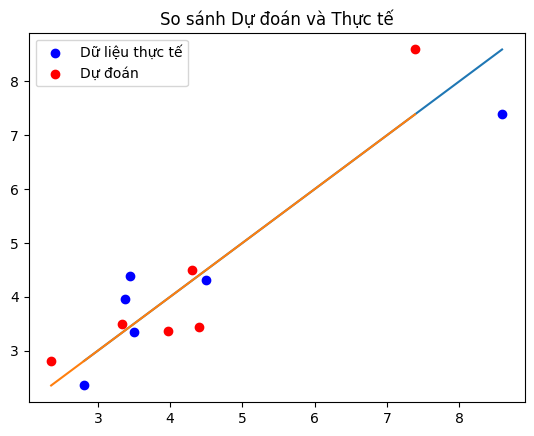

In [21]:
li_r = LinearRegression()
li_r.fit(x_train, y_train)
pred_li = li_r.predict(x_test)

import matplotlib.pyplot as plt

plt.scatter(y_test, pred_li, c='blue', label='Dữ liệu thực tế')
plt.scatter(pred_li, y_test, c='red', label='Dự đoán')

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='-')
plt.plot([min(pred_li), max(pred_li)], [min(pred_li), max(pred_li)], linestyle='-')
plt.title("So sánh Dự đoán và Thực tế")
plt.legend()

Đây là phân bố của dữ liệu đã dự đoán và thực tế

Ở bước này, ta cần tính độ đo `MSE` bằng hàm `mean_squared_error` và gán vào biến `mse_li`

In [22]:
from sklearn.metrics import mean_squared_error
mse_li = mean_squared_error(y_test, pred_li)
mse_li

0.49668377129852104